# Triton Basics

In [1]:
!nvidia-smi

Fri Apr 18 22:21:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.07             Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080        On  |   00000000:08:00.0  On |                  N/A |
| 61%   47C    P0            132W /  380W |    1508MiB /  10240MiB |     12%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import triton
import triton.language as tl

In [3]:
DEVICE = 'cuda'

## Write a reference kernel as baseline

In [4]:
def ref_vector_add(x, y):
    output = torch.add(x, y)
    return output

## Write Triton kernel

In [5]:
@triton.jit
def vector_add_kernel(x_ptr, y_ptr, output_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(0)
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)

    mask = offsets < n_elements
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    result = x + y
    tl.store(output_ptr + offsets, result, mask=mask)

## Helper function to allocate tensors

In [6]:
def triton_vector_add(x, y):
    output = torch.empty_like(x)
    size = x.numel()
    BLOCK_SIZE = 1024

    # grid = lambda META: (triton.cdiv(size, META['BLOCK_SIZE']),)
    grid = (triton.cdiv(size, BLOCK_SIZE),)
    vector_add_kernel[grid](x, y, output, size, BLOCK_SIZE=BLOCK_SIZE)

    return output


## Test the correctness

In [7]:
def test():
    size = 1024
    x = torch.randn(size, device=DEVICE)
    y = torch.randn(size, device=DEVICE)
    output_ref = ref_vector_add(x, y)

    output_triton = triton_vector_add(x, y)    

    if torch.allclose(output_ref, output_triton, atol=1e-6):
        print("✅ Triton kernel is correct!")
    else:
        print("❌ Triton kernel is incorrect.")

test()

✅ Triton kernel is correct!


## Benchmark with `triton.testing.do_bench`

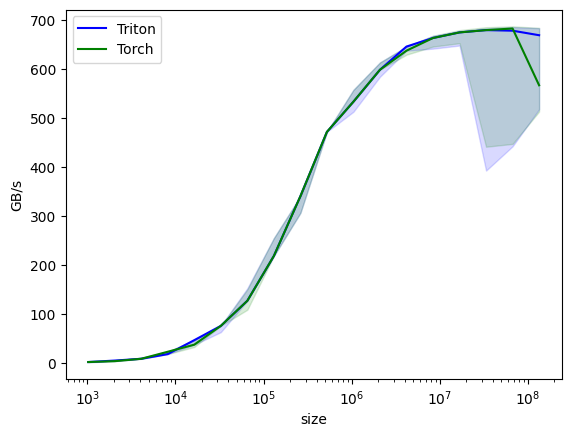

vector-add-performance:
           size      Triton       Torch
0        1024.0    3.000000    3.000000
1        2048.0    6.000000    4.800000
2        4096.0    9.600000    9.600000
3        8192.0   19.200000   24.000000
4       16384.0   47.627910   38.400001
5       32768.0   76.800002   76.800002
6       65536.0  127.999995  127.999995
7      131072.0  219.428568  219.428568
8      262144.0  341.333321  341.333321
9      524288.0  472.615390  472.615390
10    1048576.0  534.260858  534.260858
11    2097152.0  599.414644  599.414644
12    4194304.0  646.736871  638.337688
13    8388608.0  664.216187  664.216187
14   16777216.0  675.628857  675.628857
15   33554432.0  680.304525  680.304525
16   67108864.0  679.129551  683.556697
17  134217728.0  669.873949  567.718505


<Figure size 640x480 with 0 Axes>

In [8]:
import os

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2 ** i for i in range(10, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='vector-add-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: ref_vector_add(x, y), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: triton_vector_add(x, y), quantiles=quantiles)
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True, save_path=os.path.abspath("../benchmark"))